# **IBL - Anatomical Localization of Mesoscope Imaging Data**

This tutorial shows how to access data from <[DANDI:00XXXX](https://dandiarchive.org/dandiset/00XXXX/draft)> for the IBL mesoscope dataset

## Study Overview

[TODO add description]

## Contents

1. [Setup and Data Access](#setup)
2. [Anatomical Localization](#loc)

---

# 1. Setup and Data Access <a id="setup"></a>

## Import Required Libraries

In [1]:
# Core data manipulation and analysis
from pathlib import Path

import h5py

# Visualization
import matplotlib.pyplot as plt
import remfile
from dandi.dandiapi import DandiAPIClient

# NWB and DANDI access
from pynwb import NWBHDF5IO

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Data Access Functions

In [2]:
def load_nwb_from_dandi(dandiset_id, subject_id, session_id):
    """
    Load NWB file from DANDI Archive via streaming.
    """
    pattern = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}*.nwb"
    
    with DandiAPIClient() as client:
        client.dandi_authenticate()
        assets = client.get_dandiset(dandiset_id, "draft").get_assets_by_glob(
            pattern=pattern, order="path"
        )
        
        s3_urls = []
        for asset in assets:
            s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)
            s3_urls.append(s3_url)
        
        if len(s3_urls) != 1:
            raise ValueError(f"Expected 1 file, found {len(s3_urls)} for pattern {pattern}")
        
        s3_url = s3_urls[0]
    
    file = remfile.File(s3_url)
    h5_file = h5py.File(file, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwbfile = io.read()
    
    return nwbfile, io


def load_nwb_local(directory_path, subject_id, session_id):
    """
    Load NWB file from local directory.
    """
    directory_path = Path(directory_path)
    nwbfile_path = directory_path / f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_desc-processed_behavior+ophys.nwb"

    if not nwbfile_path.exists():
        raise FileNotFoundError(f"NWB file not found: {nwbfile_path}")

    io = NWBHDF5IO(path=nwbfile_path, load_namespaces=True)
    nwbfile = io.read()

    return nwbfile, io

## Stream / Load Session

In [3]:
# Load session data
dandiset_id = "00XXXX" #TODO Replace with actual DANDI dandiset ID
subject_id = "SP061"  # Example subject
session_id = "5ce2e17e-8471-42d4-8a16-21949710b328"  # EID for the session
# session_id = "42d7e11e-3185-4a79-a6ad-bbaf47366db2"  # EID for the session


# Choose data source (DANDI streaming or local)
USE_DANDI = False  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id)
else:
    # Specify your local directory path
    local_directory = "E:/IBL-mesoscope-nwbfiles/stub"  # Replace with actual path
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id)

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 This experiment aims to capture the activity of defined neural populations during the IBL decision-making task, using a 2-photon random access mesoscope. By imaging calcium activity in excitatory neurons across the dorsal cortex of transgenic mice, we seek to characterize how population-level neural activity encodes key task variables such as stimulus, choice, and bias context.
Session description:
 The task protocol(s) performed in this experimental session:
1. Cued biased choice world — a custom variant of the biased choice world task with added visual cues. The mouse performs a decision-making task: a Gabor patch appears on the left or right of the screen, and the mouse turns a steering wheel to bring it to the center. Correct responses are rewarded with water. Stimulus probability alternates between 80/20 and 20/80 blocks. All contrast levels are used (100%, 25%, 12.5%, 6.25%, 0%).
2. Passive video presentation — typically a Perl

---

# 2. Anatomical Localization <a id="loc"></a>

TODO:
Final plot --> would be nice to have a function that plot 2p_series w roi mask marked on top next to traces of the same ROI. Input of the function would only be the FOV name and ROI id  --> it will also report CCFv3 coordinates and Brain ID and metadata from linked imaging plane

=== ANATOMICAL LOCALIZATION OF ROIS ===
----------------------------------------------------------------------------------------------------
Anatomical Coordinates Table: AnatomicalCoordinatesTableCCFv3ROIFOV00
   Description: ROI centroid estimated coordinates in the CCF coordinate system for FOV_00.


,x,y,z,localized_entity,brain_region_id
id,,,,,
0,4836.478993,1124.679725,8800.388806,roi_name ...,182305693
1,4879.924038,1112.820425,8762.865861,roi_name ...,182305693
2,4988.738162,1080.179047,8633.071203,roi_name ...,450
3,4895.591782,1117.643897,8770.906492,roi_name ...,182305693
4,4936.432520,906.924806,8320.240060,roi_name ...,450


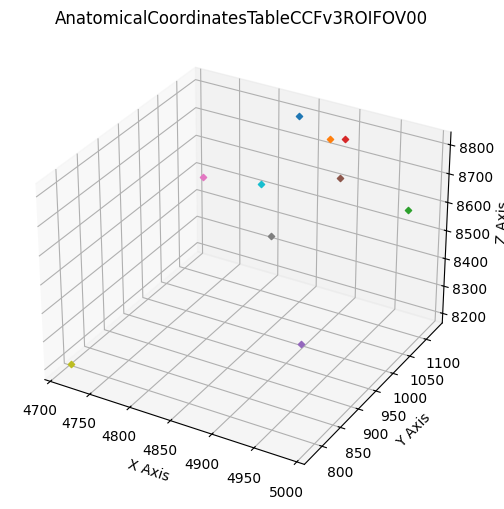

----------------------------------------------------------------------------------------------------
Anatomical Coordinates Table: AnatomicalCoordinatesTableCCFv3ROIFOV01
   Description: ROI centroid estimated coordinates in the CCF coordinate system for FOV_01.


,x,y,z,localized_entity,brain_region_id
id,,,,,
0,4552.367369,502.484944,7502.384809,roi_name ...,1006
1,4550.210004,494.938699,7484.963441,roi_name ...,1006
2,4632.963861,532.657183,7498.755583,roi_name ...,1030
3,4544.432392,501.574970,7473.098040,roi_name ...,1006
4,4565.625334,503.511376,7473.098040,roi_name ...,1006


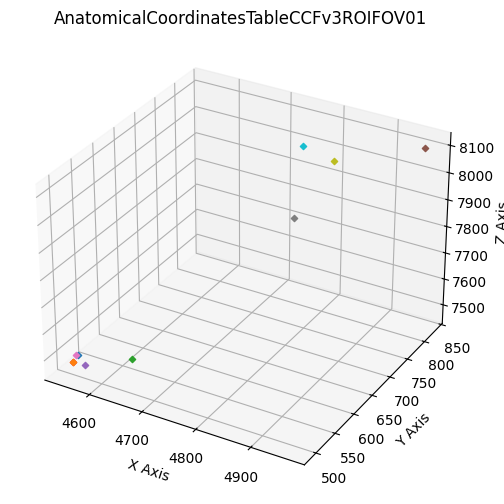

----------------------------------------------------------------------------------------------------
Anatomical Coordinates Table: AnatomicalCoordinatesTableIBLBregmaROIFOV00
   Description: ROI centroid estimated coordinates in the IBL-Bregma coordinate system for FOV_00.


,x,y,z,localized_entity,brain_region_id
id,,,,,
0,2914.442143,-580.990158,-701.521557,roi_name ...,182305693
1,2878.720299,-536.198317,-691.026076,roi_name ...,182305693
2,2755.155785,-424.010955,-662.138457,roi_name ...,450
3,2886.374980,-520.044872,-695.294849,roi_name ...,182305693
4,2457.340537,-477.938072,-508.808454,roi_name ...,450


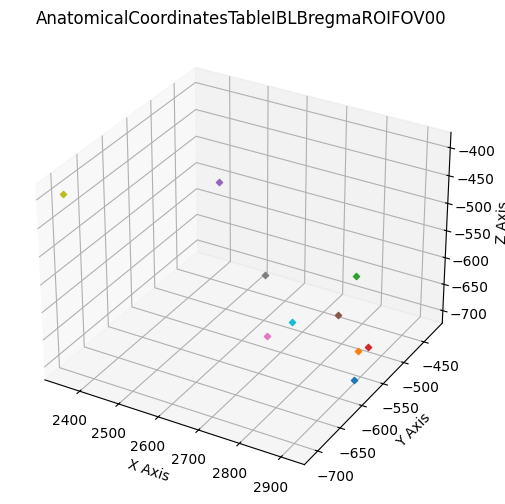

----------------------------------------------------------------------------------------------------
Anatomical Coordinates Table: AnatomicalCoordinatesTableIBLBregmaROIFOV01
   Description: ROI centroid estimated coordinates in the IBL-Bregma coordinate system for FOV_01.


,x,y,z,localized_entity,brain_region_id
id,,,,,
0,1678.742338,-873.909242,-150.879176,roi_name ...,1006
1,1662.157196,-876.133486,-144.200748,roi_name ...,1006
2,1675.287315,-790.814260,-177.581607,roi_name ...,1030
3,1650.861334,-882.090204,-150.073849,roi_name ...,1006
4,1650.861334,-860.240280,-151.787568,roi_name ...,1006


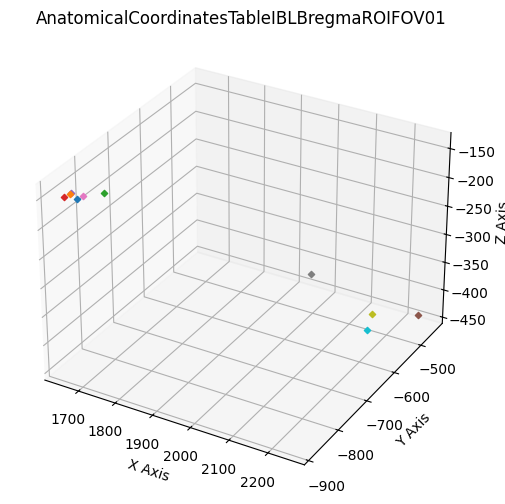

----------------------------------------------------------------------------------------------------


In [4]:
print("=== ANATOMICAL LOCALIZATION OF ROIS ===")
print("-" * 100)
for table_name in nwbfile.lab_meta_data["localization"].anatomical_coordinates_tables:
    table = nwbfile.lab_meta_data["localization"].anatomical_coordinates_tables[table_name]
    print(f"Anatomical Coordinates Table: {table_name}")
    print(f"   Description: {table.description}")
    display(table.to_dataframe().head(5))  # Print first 5 rows as example
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i in range(10):
        ax.scatter3D(table.x[i], table.y[i], table.z[i], marker="D", s=10)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    ax.set_title(f"{table_name.replace('_', ' ')}")
    plt.show()
    print("-" * 100)

=== SUMMARY IMAGES: ===
----------------------------------------------------------------------------------------------------
Plane Segmentation: MeanImageFOV00
----------------------------------------------------------------------------------------------------
   Description: The mean image for FOV_00 (UUID: CCE276EFA6244E74).
   Dimensions: (512, 512)
----------------------------------------------------------------------------------------------------
Plane Segmentation: MeanImageFOV01
----------------------------------------------------------------------------------------------------
   Description: The mean image for FOV_01 (UUID: FBEB99A903F6F6DB).
   Dimensions: (512, 512)
----------------------------------------------------------------------------------------------------


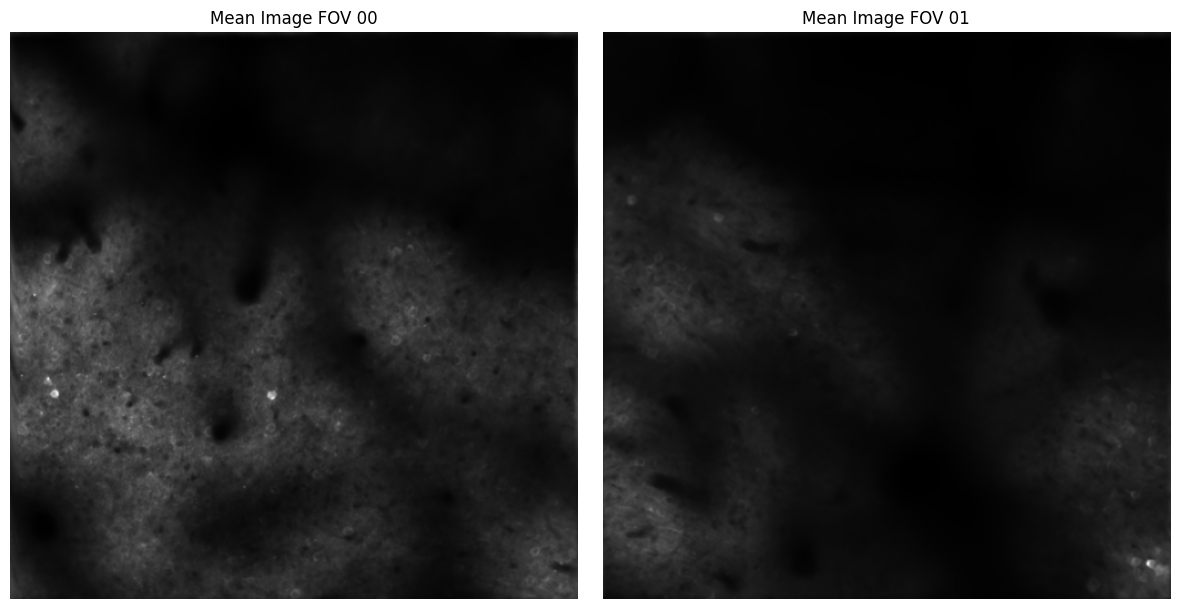

In [8]:
print(f"=== SUMMARY IMAGES: ===")
print("-" * 100)
for name, proc in nwbfile.processing["ophys"].data_interfaces.items():
    if name == "SegmentationImages":
        summary_images_module = nwbfile.processing["ophys"][name]
        fig, axes = plt.subplots(1, len(summary_images_module.images.items()), sharex=True, sharey=True, dpi=100)
        for i, (_, summary_image) in enumerate(summary_images_module.images.items()):
            print(f"Plane Segmentation: {summary_image.name}")
            print("-" * 100)
            print(f"   Description: {summary_image.description}")
            print(f"   Dimensions: {summary_image.data.shape}")
            print("-" * 100)
            axes[i].imshow(summary_image.data, cmap="gray")
            axes[i].set_title(f"Mean Image FOV 0{i}")
            axes[i].axis("off")
plt.tight_layout()
plt.show()

In [12]:
print("=== ANATOMICAL LOCALIZATION OF FULL FOV ===")
print("-" * 100)
for coordinates_image_name in nwbfile.lab_meta_data["localization"].anatomical_coordinates_images:
    coordinates_image = nwbfile.lab_meta_data["localization"].anatomical_coordinates_images[coordinates_image_name]
    print(f"Anatomical Coordinates Image: {coordinates_image_name}")
    print("-" * 100)    
    print(f"   Description: {coordinates_image.description}")
    print(f"   Space: {coordinates_image.space.name}")
    print(f"   Source TwoPhotonSeries: {coordinates_image.localized_entity.name}")
    print("-" * 100)


=== ANATOMICAL LOCALIZATION OF FULL FOV ===
----------------------------------------------------------------------------------------------------
Anatomical Coordinates Image: AnatomicalCoordinatesImageCCFv3FOV00
----------------------------------------------------------------------------------------------------
   Description: Mean image estimated coordinates in the CCF coordinate system for FOV_00.
   Space: AllenCCFv3
   Source TwoPhotonSeries: MotionCorrectedTwoPhotonSeriesFOV00
----------------------------------------------------------------------------------------------------
Anatomical Coordinates Image: AnatomicalCoordinatesImageCCFv3FOV01
----------------------------------------------------------------------------------------------------
   Description: Mean image estimated coordinates in the CCF coordinate system for FOV_01.
   Space: AllenCCFv3
   Source TwoPhotonSeries: MotionCorrectedTwoPhotonSeriesFOV01
----------------------------------------------------------------------

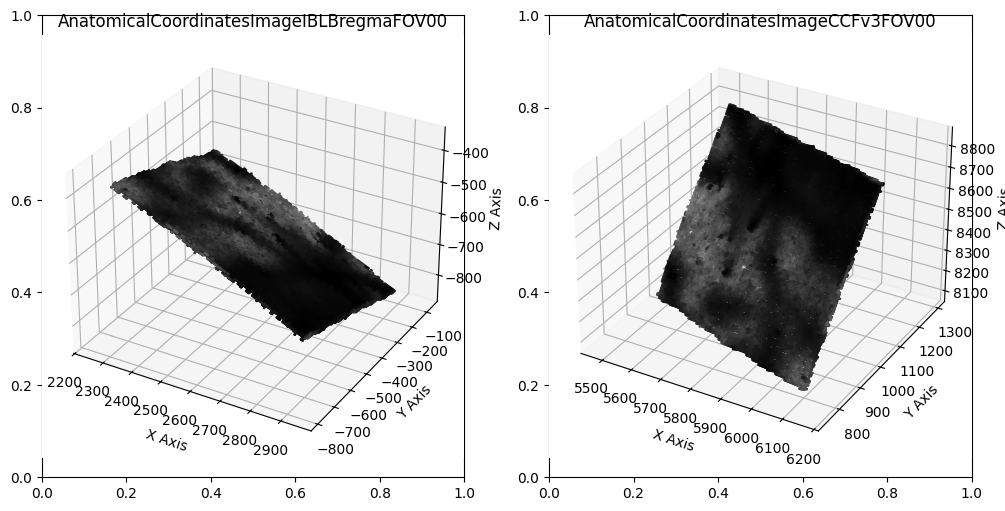

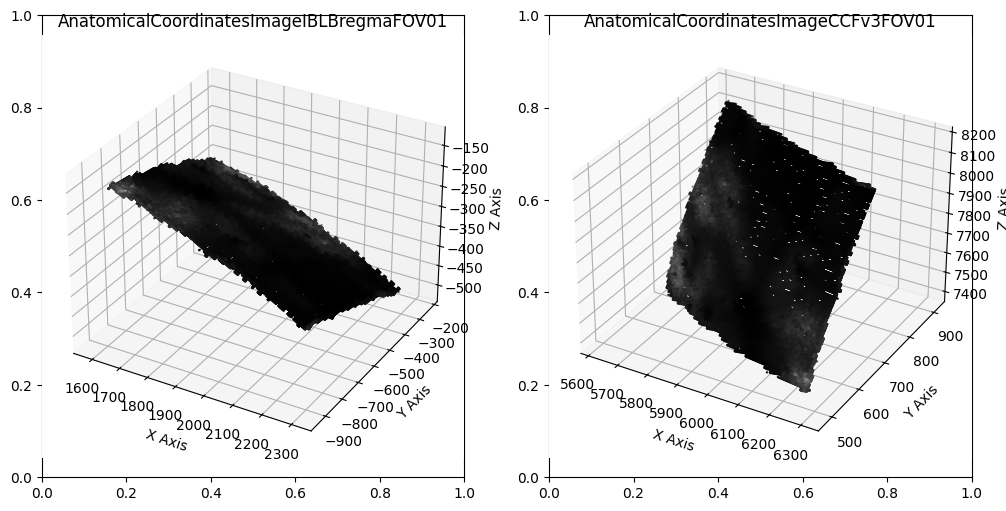

In [20]:
for summary_image_name, summary_image in summary_images_module.images.items():
    FOV_number = summary_image_name.split("FOV")[-1]  # Extract FOV identifier from image name
    FOV_name = f"FOV{FOV_number}"
    fig, axes = plt.subplots(1, 2, dpi=100) # Two spaces: IBL Bregma and Allen CCF
    groups = summary_image.data[:]
    ibl_image = nwbfile.lab_meta_data["localization"].anatomical_coordinates_images[
        f"AnatomicalCoordinatesImageIBLBregma{FOV_name}"
    ]
    ccf_image = nwbfile.lab_meta_data["localization"].anatomical_coordinates_images[
        f"AnatomicalCoordinatesImageCCFv3{FOV_name}"
    ]
    axes[0] = fig.add_subplot(121, projection="3d")
    axes[0].scatter3D(ibl_image.x, ibl_image.y, ibl_image.z, marker=".", c=groups, cmap="Greys_r", s=1)
    axes[0].set_xlabel("X Axis")
    axes[0].set_ylabel("Y Axis")
    axes[0].set_zlabel("Z Axis")
    axes[0].set_title(f"{ibl_image.name.replace('_', ' ')}")
    axes[1] = fig.add_subplot(122, projection="3d")
    axes[1].scatter3D(ccf_image.x, ccf_image.y, ccf_image.z, marker=".", c=groups, cmap="Greys_r", s=1)
    axes[1].set_xlabel("X Axis")
    axes[1].set_ylabel("Y Axis")
    axes[1].set_zlabel("Z Axis")
    axes[1].set_title(f"{ccf_image.name.replace('_', ' ')}")
    plt.show()